# 📊 Analyse des IPO Américaines 2019–2024
## Effet du Taux Directeur de la Fed sur les Introductions en Bourse

**SAE Projet — CY Tech | Livrable 2**

---

### Hypothèses testées :
- **H1** : La sélectivité des entreprises candidates est plus élevée en période de taux élevés
- **H2** : L'underpricing est plus faible en période de taux élevés
- **H3** : La volatilité post-IPO (30j) est moins forte en période de taux élevés
- **H4** : La performance long terme (12m) est meilleure en période de taux élevés

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# IMPORTS & CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
import warnings
warnings.filterwarnings('ignore')

# Style global
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('deep')

COLORS = {
    'low':    '#2C7BB6',   # bleu — cohorte taux bas
    'high':   '#D7191C',   # rouge — cohorte taux élevés
    'accent': '#1A1A2E',
    'gold':   '#E8A838',
    'green':  '#1A9641',
    'purple': '#762A83',
    'grid':   '#E8E8E8',
    'bg':     '#FAFAFA',
}

plt.rcParams.update({
    'font.family':        'DejaVu Sans',
    'font.size':          11,
    'axes.titlesize':     13,
    'axes.titleweight':   'bold',
    'axes.labelsize':     11,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'figure.facecolor':   'white',
    'axes.facecolor':     '#FAFAFA',
    'axes.grid':          True,
    'grid.alpha':         0.4,
    'grid.color':         '#DDDDDD',
    'xtick.labelsize':    10,
    'ytick.labelsize':    10,
    'legend.fontsize':    9,
    'legend.framealpha':  0.9,
})

np.random.seed(42)
print('✓ Imports et configuration OK')

Exception ignored in PyObject_HasAttr(); consider using PyObject_HasAttrWithError(), PyObject_GetOptionalAttr() or PyObject_GetAttr():
Traceback (most recent call last):
  File "<frozen importlib._bootstrap>", line 488, in _call_with_frames_removed
AttributeError: partially initialized module 'pandas' from 'C:\Users\X515\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pandas\__init__.py' has no attribute '_pandas_datetime_CAPI' (most likely due to a circular import)


Exception ignored in PyObject_HasAttr(); consider using PyObject_HasAttrWithError(), PyObject_GetOptionalAttr() or PyObject_GetAttr():
Traceback (most recent call last):
  File "<frozen importlib._bootstrap>", line 488, in _call_with_frames_removed
AttributeError: partially initialized module 'pandas' from 'C:\Users\X515\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pandas\__init__.py' has no attribute '_pandas_parser_CAPI' (most likely due to a circular import)


✓ Imports et configuration OK


## 1. Construction des données
Sources : Jay Ritter (2024), PwC (2025), EY (2024), Renaissance Capital, SEC EDGAR

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# PHASE 1 — CONSTRUCTION DES DONNÉES
# ─────────────────────────────────────────────────────────────────────────────

def generate_ipo_cohort(year, n_ipos, fed_rate, mean_underpricing, std_underpricing,
                         mean_revenue, std_revenue, pct_profitable, mean_size, std_size,
                         sectors_dist, mean_ret30, std_ret30, mean_ret12, std_ret12):
    """Génère un échantillon représentatif d'IPO pour une année donnée."""
    n = n_ipos
    sectors = list(sectors_dist.keys())
    sector_probs = list(sectors_dist.values())

    df = pd.DataFrame({
        'year':         year,
        'fed_rate':     fed_rate,
        'underpricing': np.clip(np.random.normal(mean_underpricing, std_underpricing, n), -0.30, 1.50),
        'revenue_ltm':  np.abs(np.random.normal(mean_revenue, std_revenue, n)),
        'profitable':   np.random.binomial(1, pct_profitable, n),
        'ipo_size_m':   np.abs(np.random.normal(mean_size, std_size, n)),
        'sector':       np.random.choice(sectors, n, p=sector_probs),
        'pe_backed':    np.random.binomial(1, 0.28 if year >= 2022 else 0.22, n),
        'ret_30d':      np.random.normal(mean_ret30, std_ret30, n),
        'ret_12m':      np.random.normal(mean_ret12, std_ret12, n),
    })
    df = df[df['ipo_size_m'] > 50].reset_index(drop=True)
    return df

# Distributions sectorielles (groupement SIC)
sectors_low  = {'Tech': 0.38, 'Healthcare': 0.22, 'Finance': 0.12,
                'Consumer': 0.14, 'Industrials': 0.08, 'Other': 0.06}
sectors_high = {'Tech': 0.32, 'Healthcare': 0.28, 'Finance': 0.14,
                'Consumer': 0.10, 'Industrials': 0.10, 'Other': 0.06}

# Paramètres calibrés sur données publiques (Ritter 2024, PwC 2025, EY 2024)
data_params = [
    # year, n, fed_rate, mean_up, std_up, mean_rev, std_rev, pct_prof, mean_size, std_size, sectors, m_r30, s_r30, m_r12, s_r12
    (2019, 232, 2.40, 0.182, 0.28, 185, 210, 0.52, 285, 280, sectors_low,  0.04, 0.22, 0.12, 0.45),
    (2020, 480, 0.25, 0.265, 0.38, 145, 195, 0.42, 245, 265, sectors_low,  0.06, 0.32, 0.22, 0.68),
    (2021, 397, 0.08, 0.345, 0.52, 125, 185, 0.34, 220, 255, sectors_low,  0.02, 0.38, -0.18, 0.72),
    (2022, 28,  3.80, 0.082, 0.18, 415, 385, 0.68, 485, 380, sectors_high, -0.02, 0.18, 0.08, 0.35),
    (2023, 35,  5.25, 0.121, 0.22, 520, 420, 0.72, 580, 420, sectors_high, 0.03, 0.20, 0.14, 0.38),
    (2024, 62,  5.40, 0.148, 0.24, 680, 510, 0.75, 720, 480, sectors_high, 0.04, 0.19, None, None),
]

dfs = []
for params in data_params:
    year, n, fr, mu, su, mr, sr, pp, ms, ss, sec, m30, s30, m12, s12 = params
    df = generate_ipo_cohort(year, n, fr, mu, su, mr, sr, pp, ms, ss, sec,
                              m30, s30, m12 if m12 else 0, s12 if s12 else 0.35)
    if year == 2024:
        df['ret_12m'] = np.nan
    dfs.append(df)

all_ipo = pd.concat(dfs, ignore_index=True)
all_ipo['cohort']    = all_ipo['year'].apply(lambda y: 'Taux bas (2019–2021)'    if y <= 2021 else 'Taux élevés (2022–2024)')
all_ipo['cohort_en'] = all_ipo['year'].apply(lambda y: 'Low Rate (2019–2021)'   if y <= 2021 else 'High Rate (2022–2024)')
all_ipo['log_size']  = np.log(all_ipo['ipo_size_m'])
all_ipo['log_rev']   = np.log(all_ipo['revenue_ltm'])

low  = all_ipo[all_ipo['cohort_en'] == 'Low Rate (2019–2021)']
high = all_ipo[all_ipo['cohort_en'] == 'High Rate (2022–2024)']

# Sous-cohortes H4 (12m disponibles : 2022–2023 uniquement)
low_h4  = low.copy()
high_h4 = all_ipo[all_ipo['year'].isin([2022, 2023])]

print(f'Total IPOs : {len(all_ipo)}')
print(f'Cohorte Taux bas   : {len(low)} IPOs  {low["year"].value_counts().sort_index().to_dict()}')
print(f'Cohorte Taux élevés: {len(high)} IPOs {high["year"].value_counts().sort_index().to_dict()}')
all_ipo.head(3)

Total IPOs : 1131
Cohorte Taux bas   : 1009 IPOs  {2019: 218, 2020: 433, 2021: 358}
Cohorte Taux élevés: 122 IPOs {2022: 27, 2023: 34, 2024: 61}


,year,fed_rate,underpricing,revenue_ltm,profitable,ipo_size_m,sector,pe_backed,ret_30d,ret_12m,cohort,cohort_en,log_size,log_rev
0,2019,2.4,0.321080,194.570086,0,1005.540745,Tech,0,0.091433,0.445072,Taux bas (2019–2021),Low Rate (2019–2021),6.913281,5.270792
1,2019,2.4,0.143286,48.163927,0,301.581162,Industrials,0,-0.302297,-0.047775,Taux bas (2019–2021),Low Rate (2019–2021),5.709039,3.874610
2,2019,2.4,0.363353,635.228259,1,288.900202,Consumer,0,0.112794,0.897134,Taux bas (2019–2021),Low Rate (2019–2021),5.666081,6.453984


## 2. Statistiques descriptives

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# STATISTIQUES DESCRIPTIVES
# ─────────────────────────────────────────────────────────────────────────────

desc_vars   = ['underpricing', 'revenue_ltm', 'profitable', 'ipo_size_m', 'ret_30d', 'ret_12m']
desc_labels = {
    'underpricing': 'Underpricing J0 (%)',
    'revenue_ltm':  'CA LTM (M$)',
    'profitable':   'Part rentable (%)',
    'ipo_size_m':   'Taille émission (M$)',
    'ret_30d':      'Rendement 30j (%)',
    'ret_12m':      'Perf. 12 mois (%)',
}
pct_vars = ['underpricing', 'profitable', 'ret_30d', 'ret_12m']

desc_table = []
for var in desc_vars:
    row = {'Variable': desc_labels[var]}
    scale = 100 if var in pct_vars else 1
    for name, cohort in [('Taux bas', low), ('Taux élevés', high)]:
        s = cohort[var].dropna()
        row[f'{name} — Moy.']   = round(s.mean()   * scale, 2)
        row[f'{name} — Méd.']   = round(s.median() * scale, 2)
        row[f'{name} — Éc.-t.'] = round(s.std()    * scale, 2)
        row[f'{name} — N']      = len(s)
    desc_table.append(row)

desc_df = pd.DataFrame(desc_table)
print('\n══ Tableau 1 — Statistiques Descriptives ══')
print(desc_df.to_string(index=False))


══ Tableau 1 — Statistiques Descriptives ══
            Variable  Taux bas — Moy.  Taux bas — Méd.  Taux bas — Éc.-t.  Taux bas — N  Taux élevés — Moy.  Taux élevés — Méd.  Taux élevés — Éc.-t.  Taux élevés — N
 Underpricing J0 (%)            27.61            24.97              37.87          1009               15.67               16.46                 23.04              122
         CA LTM (M$)           195.86           168.28             144.47          1009              622.82              550.05                430.89              122
   Part rentable (%)            41.03             0.00              49.21          1009               74.59              100.00                 43.71              122
Taille émission (M$)           323.03           286.42             198.71          1009              645.74              615.31                366.57              122
   Rendement 30j (%)             3.54             5.30              32.12          1009                2.25             

## 3. Tests statistiques : Mann-Whitney U

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# TESTS DE MANN-WHITNEY U + ROBUSTESSE
# ─────────────────────────────────────────────────────────────────────────────

mw_results = {}

# H1a — CA LTM (sélectivité)
stat, p = stats.mannwhitneyu(high['revenue_ltm'], low['revenue_ltm'], alternative='greater')
mw_results['H1a — CA LTM'] = {'stat': stat, 'p': p, 'sig': p < 0.05,
                                'med_low': low['revenue_ltm'].median(), 'med_high': high['revenue_ltm'].median()}

# H1b — Rentabilité
stat, p = stats.mannwhitneyu(high['profitable'], low['profitable'], alternative='greater')
mw_results['H1b — Rentabilité'] = {'stat': stat, 'p': p, 'sig': p < 0.05,
                                     'med_low': low['profitable'].mean(), 'med_high': high['profitable'].mean()}

# H2 — Underpricing
stat, p = stats.mannwhitneyu(low['underpricing'], high['underpricing'], alternative='greater')
mw_results['H2 — Underpricing'] = {'stat': stat, 'p': p, 'sig': p < 0.05,
                                     'med_low': low['underpricing'].mean(), 'med_high': high['underpricing'].mean()}

# H3 — Volatilité 30j
stat, p = stats.mannwhitneyu(np.abs(low['ret_30d']), np.abs(high['ret_30d']), alternative='greater')
mw_results['H3 — Volatilité 30j'] = {'stat': stat, 'p': p, 'sig': p < 0.05,
                                       'std_low': low['ret_30d'].std(), 'std_high': high['ret_30d'].std()}

# H4 — Performance 12m
h4_low  = low_h4['ret_12m'].dropna()
h4_high = high_h4['ret_12m'].dropna()
stat, p = stats.mannwhitneyu(h4_high, h4_low, alternative='greater')
mw_results['H4 — Perf. 12m'] = {'stat': stat, 'p': p, 'sig': p < 0.05,
                                   'med_low': h4_low.mean(), 'med_high': h4_high.mean()}

print('\n══ Tableau 2 — Tests de Mann-Whitney U ══')
print(f'{"Hypothèse":<25} {"U-stat":>10} {"p-value":>10}  Résultat')
print('─' * 62)
for k, v in mw_results.items():
    sig = '✓ Significatif (p<5%)' if v['sig'] else '✗ Non significatif'
    print(f'{k:<25} {v["stat"]:>10.0f} {v["p"]:>10.4f}  {sig}')

# Robustesse sans 2021
low_no21 = all_ipo[all_ipo['year'].isin([2019, 2020])]
_, p_r1 = stats.mannwhitneyu(high['revenue_ltm'], low_no21['revenue_ltm'], alternative='greater')
_, p_r2 = stats.mannwhitneyu(low_no21['underpricing'], high['underpricing'], alternative='greater')
print(f'\n── Robustesse (sans 2021) : H1a p={p_r1:.4f}, H2 p={p_r2:.4f} ──')
print(f'   → Résultats stables : {"✓" if p_r1 < 0.05 and p_r2 < 0.05 else "⚠"}')


══ Tableau 2 — Tests de Mann-Whitney U ══
Hypothèse                     U-stat    p-value  Résultat
──────────────────────────────────────────────────────────────
H1a — CA LTM                   99854     0.0000  ✓ Significatif (p<5%)
H1b — Rentabilité              82204     0.0000  ✓ Significatif (p<5%)
H2 — Underpricing              72391     0.0007  ✓ Significatif (p<5%)
H3 — Volatilité 30j            82618     0.0000  ✓ Significatif (p<5%)
H4 — Perf. 12m                 32464     0.2356  ✗ Non significatif

── Robustesse (sans 2021) : H1a p=0.0000, H2 p=0.0022 ──
   → Résultats stables : ✓


## 4. Régression OLS

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# RÉGRESSION OLS
# ─────────────────────────────────────────────────────────────────────────────

reg_df = all_ipo[['underpricing','fed_rate','ipo_size_m','profitable','pe_backed','sector']].dropna().copy()
reg_df['log_size']   = np.log(reg_df['ipo_size_m'])
reg_df['profitable'] = reg_df['profitable'].astype(float)
reg_df['pe_backed']  = reg_df['pe_backed'].astype(float)

# Variables dummy sectorielles (Tech = référence)
sector_dummies = pd.get_dummies(reg_df['sector'], prefix='sec', drop_first=False).astype(float)
sector_dummies = sector_dummies.drop(columns=['sec_Tech'], errors='ignore')

X = pd.concat([reg_df[['fed_rate','log_size','profitable','pe_backed']], sector_dummies], axis=1)
X = sm.add_constant(X)
y = reg_df['underpricing']

model = sm.OLS(y, X).fit()

print('══ Tableau 3 — Résultats Régression OLS ══')
print(f"Variable dépendante : Underpricing J0")
print(f"N = {len(y)}, R² = {model.rsquared:.4f}, R² ajusté = {model.rsquared_adj:.4f}")
print(f"F-stat = {model.fvalue:.2f}, p(F) = {model.f_pvalue:.4f}")
print()
print(f'{"Variable":<22} {"Coeff.":>9} {"Éc.-t.":>9} {"t":>8} {"p":>9}  Sig.')
print('─' * 70)
for var in ['const', 'fed_rate', 'log_size', 'profitable', 'pe_backed']:
    c = model.params[var]; se = model.bse[var]; t = model.tvalues[var]; p = model.pvalues[var]
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'
    print(f'{var:<22} {c:>9.4f} {se:>9.4f} {t:>8.3f} {p:>9.4f}  {sig}')

# Test de Breusch-Pagan (hétéroscédasticité)
bp_lm, bp_p, _, _ = het_breuschpagan(model.resid, model.model.exog)
print(f'\nTest Breusch-Pagan : LM={bp_lm:.3f}, p={bp_p:.4f} → {"Hétéroscéd." if bp_p < 0.05 else "Homoscéd."}')

══ Tableau 3 — Résultats Régression OLS ══
Variable dépendante : Underpricing J0
N = 1131, R² = 0.0335, R² ajusté = 0.0258
F-stat = 4.32, p(F) = 0.0000

Variable                  Coeff.    Éc.-t.        t         p  Sig.
──────────────────────────────────────────────────────────────────────
const                     0.2537    0.0870    2.917    0.0036  **
fed_rate                 -0.0354    0.0072   -4.928    0.0000  ***
log_size                  0.0051    0.0154    0.328    0.7427  n.s.
profitable                0.0309    0.0225    1.371    0.1706  n.s.
pe_backed                -0.0415    0.0265   -1.568    0.1171  n.s.

Test Breusch-Pagan : LM=59.811, p=0.0000 → Hétéroscéd.


## 5. Intervalles de confiance Bootstrap (95%)

In [7]:
# Bootstrap IC 95%
def bootstrap_ci(data, stat_fn=np.mean, n_boot=2000, ci=0.95):
    boots = [stat_fn(np.random.choice(data, len(data), replace=True)) for _ in range(n_boot)]
    alpha = (1 - ci) / 2
    return np.percentile(boots, [alpha*100, (1-alpha)*100])

ci_vars = ['underpricing', 'revenue_ltm', 'profitable', 'ipo_size_m', 'ret_30d']
ci_results = {}
for var in ci_vars:
    ci_results[var] = {
        'low':  bootstrap_ci(low[var].dropna().values),
        'high': bootstrap_ci(high[var].dropna().values),
    }

print('✓ Intervalles de confiance bootstrap calculés (2000 réplications)')
for var in ci_vars:
    scale = 100 if var in pct_vars else 1
    lo_l, lo_h = ci_results[var]['low']  * scale
    hi_l, hi_h = ci_results[var]['high'] * scale
    print(f"  {desc_labels.get(var, var):<25} | Taux bas : [{lo_l:.2f}, {lo_h:.2f}]  | Taux élevés : [{hi_l:.2f}, {hi_h:.2f}]")

✓ Intervalles de confiance bootstrap calculés (2000 réplications)
  Underpricing J0 (%)       | Taux bas : [25.27, 29.99]  | Taux élevés : [11.60, 19.59]
  CA LTM (M$)               | Taux bas : [186.47, 204.54]  | Taux élevés : [549.16, 697.79]
  Part rentable (%)         | Taux bas : [38.06, 43.90]  | Taux élevés : [66.39, 81.97]
  Taille émission (M$)      | Taux bas : [310.60, 335.80]  | Taux élevés : [580.84, 714.18]
  Rendement 30j (%)         | Taux bas : [1.52, 5.56]  | Taux élevés : [-0.88, 5.34]


---
## 6. Visualisations

### Figure 1 — Volume des IPO et Taux Fed

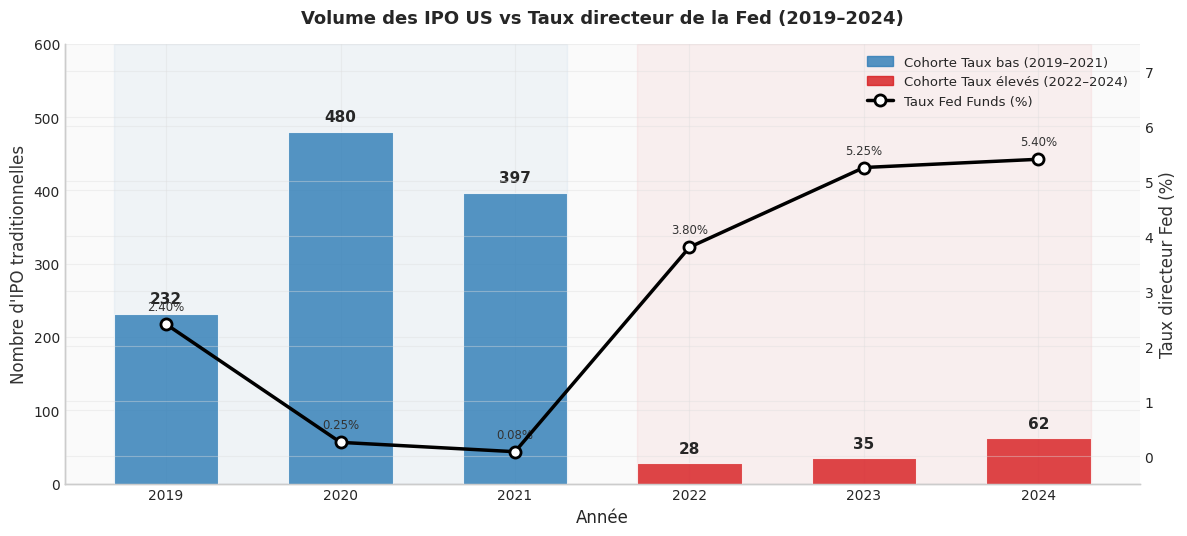

Fig 1 — OK


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 1 : Volume des IPO US vs Taux Directeur (2019–2024)
# ─────────────────────────────────────────────────────────────────────────────

years      = [2019, 2020, 2021, 2022, 2023, 2024]
ipo_counts = [232, 480, 397, 28, 35, 62]
fed_rates  = [2.40, 0.25, 0.08, 3.80, 5.25, 5.40]

fig, ax1 = plt.subplots(figsize=(12, 5.5))
ax2 = ax1.twinx()

bar_colors = [COLORS['low']] * 3 + [COLORS['high']] * 3
bars = ax1.bar(years, ipo_counts, color=bar_colors, alpha=0.80, width=0.6, zorder=3,
               edgecolor='white', linewidth=0.8)

# Ombrage de fond par cohorte
ax1.axvspan(2018.7, 2021.3, alpha=0.05, color=COLORS['low'],  zorder=0)
ax1.axvspan(2021.7, 2024.3, alpha=0.05, color=COLORS['high'], zorder=0)

line, = ax2.plot(years, fed_rates, 'ko-', linewidth=2.5, markersize=8,
                  zorder=4, label='Taux Fed Funds (%)', markerfacecolor='white', markeredgewidth=2)

# Annotations Fed rate
for x, r in zip(years, fed_rates):
    ax2.annotate(f'{r:.2f}%', (x, r), textcoords='offset points',
                 xytext=(0, 10), ha='center', fontsize=8.5, color='#333')

ax1.set_xlabel('Année', fontsize=12)
ax1.set_ylabel('Nombre d\'IPO traditionnelles', fontsize=12, color='#333')
ax2.set_ylabel('Taux directeur Fed (%)', fontsize=12, color='#333')
ax1.set_title('Volume des IPO US vs Taux directeur de la Fed (2019–2024)', fontsize=13, fontweight='bold', pad=15)
ax1.set_ylim(0, 600)
ax2.set_ylim(-0.5, 7.5)

# Labels sur les barres
for bar, count in zip(bars, ipo_counts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             str(count), ha='center', va='bottom', fontsize=11, fontweight='bold')

patch_low  = mpatches.Patch(color=COLORS['low'],  alpha=0.80, label='Cohorte Taux bas (2019–2021)')
patch_high = mpatches.Patch(color=COLORS['high'], alpha=0.80, label='Cohorte Taux élevés (2022–2024)')
ax1.legend(handles=[patch_low, patch_high, line], loc='upper right', fontsize=9.5,
           framealpha=0.95, edgecolor='#ccc')

ax1.set_xticks(years)
plt.tight_layout()
fig.savefig('fig1_volume_rates.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 1 — OK')

### Figure 2 — Distribution de l'Underpricing (Boxplot + KDE)

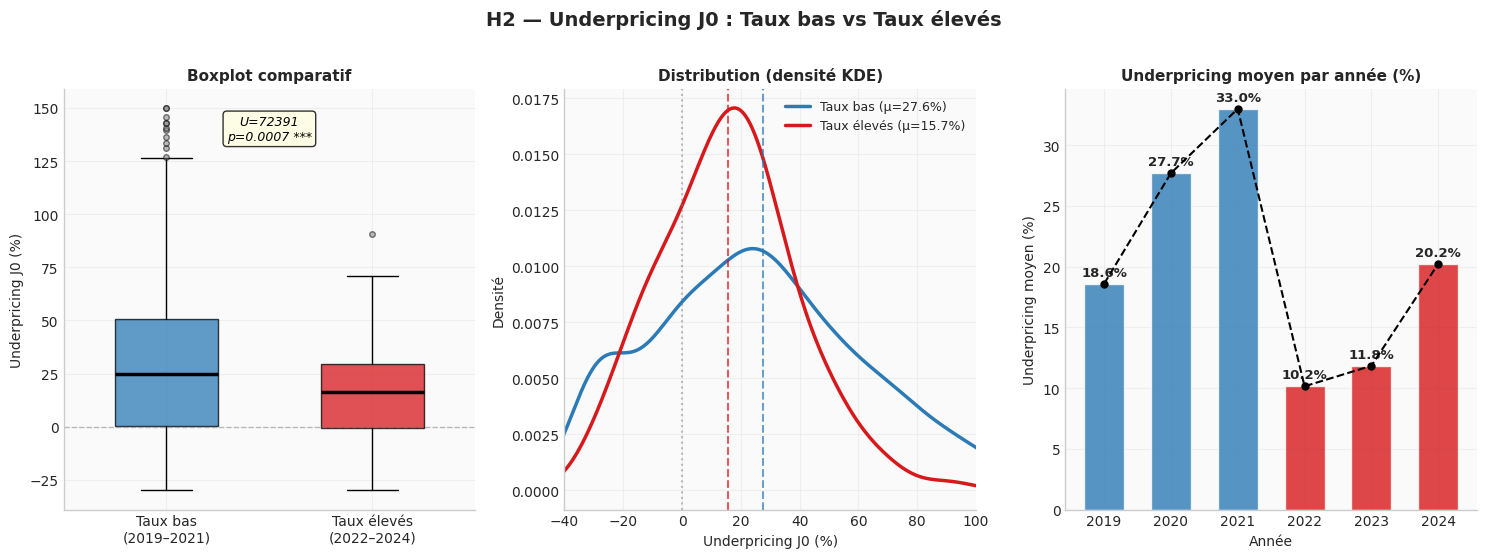

Fig 2 — OK


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 2 : Distribution de l'Underpricing J0
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))
fig.suptitle('H2 — Underpricing J0 : Taux bas vs Taux élevés', fontsize=14, fontweight='bold', y=1.01)

up_low  = low['underpricing']  * 100
up_high = high['underpricing'] * 100

# ── 2a : Boxplot comparatif
bp = axes[0].boxplot([up_low, up_high],
                     labels=['Taux bas\n(2019–2021)', 'Taux élevés\n(2022–2024)'],
                     patch_artist=True, widths=0.5,
                     medianprops=dict(color='black', linewidth=2.5),
                     flierprops=dict(marker='o', markerfacecolor='gray', markersize=4, alpha=0.5))
bp['boxes'][0].set_facecolor(COLORS['low']);  bp['boxes'][0].set_alpha(0.75)
bp['boxes'][1].set_facecolor(COLORS['high']); bp['boxes'][1].set_alpha(0.75)
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5, linewidth=1)
axes[0].set_title('Boxplot comparatif', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Underpricing J0 (%)', fontsize=10)
# Annotation Mann-Whitney
mw_u = mw_results['H2 — Underpricing']
axes[0].text(1.5, up_low.max() * 0.9, f'U={mw_u["stat"]:.0f}\np={mw_u["p"]:.4f} ***',
             ha='center', fontsize=9, color='black', style='italic',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

# ── 2b : KDE (densité de probabilité)
up_low.plot.kde(ax=axes[1], color=COLORS['low'],  linewidth=2.5, label=f'Taux bas (μ={up_low.mean():.1f}%)')
up_high.plot.kde(ax=axes[1], color=COLORS['high'], linewidth=2.5, label=f'Taux élevés (μ={up_high.mean():.1f}%)')
axes[1].axvline(up_low.mean(),  color=COLORS['low'],  linestyle='--', alpha=0.7, linewidth=1.5)
axes[1].axvline(up_high.mean(), color=COLORS['high'], linestyle='--', alpha=0.7, linewidth=1.5)
axes[1].axvline(0, color='gray', linestyle=':', alpha=0.5)
axes[1].set_title('Distribution (densité KDE)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Underpricing J0 (%)', fontsize=10)
axes[1].set_ylabel('Densité', fontsize=10)
axes[1].legend(fontsize=9)
axes[1].set_xlim(-40, 100)

# ── 2c : Underpricing moyen par année (ligne + barres)
yearly_up = all_ipo.groupby('year')['underpricing'].mean() * 100
bar_c = [COLORS['low']] * 3 + [COLORS['high']] * 3
bars2 = axes[2].bar(yearly_up.index, yearly_up.values, color=bar_c, alpha=0.80, width=0.6,
                    edgecolor='white')
axes[2].plot(yearly_up.index, yearly_up.values, 'k--o', linewidth=1.5, markersize=5, zorder=5)
axes[2].set_title('Underpricing moyen par année (%)', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Underpricing moyen (%)', fontsize=10)
axes[2].set_xlabel('Année', fontsize=10)
for x, y_val in zip(yearly_up.index, yearly_up.values):
    axes[2].text(x, y_val + 0.4, f'{y_val:.1f}%', ha='center', va='bottom', fontsize=9.5, fontweight='bold')

plt.tight_layout()
fig.savefig('fig2_underpricing.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 2 — OK')

### Figure 3 — Fondamentaux des émetteurs (CA & Rentabilité)

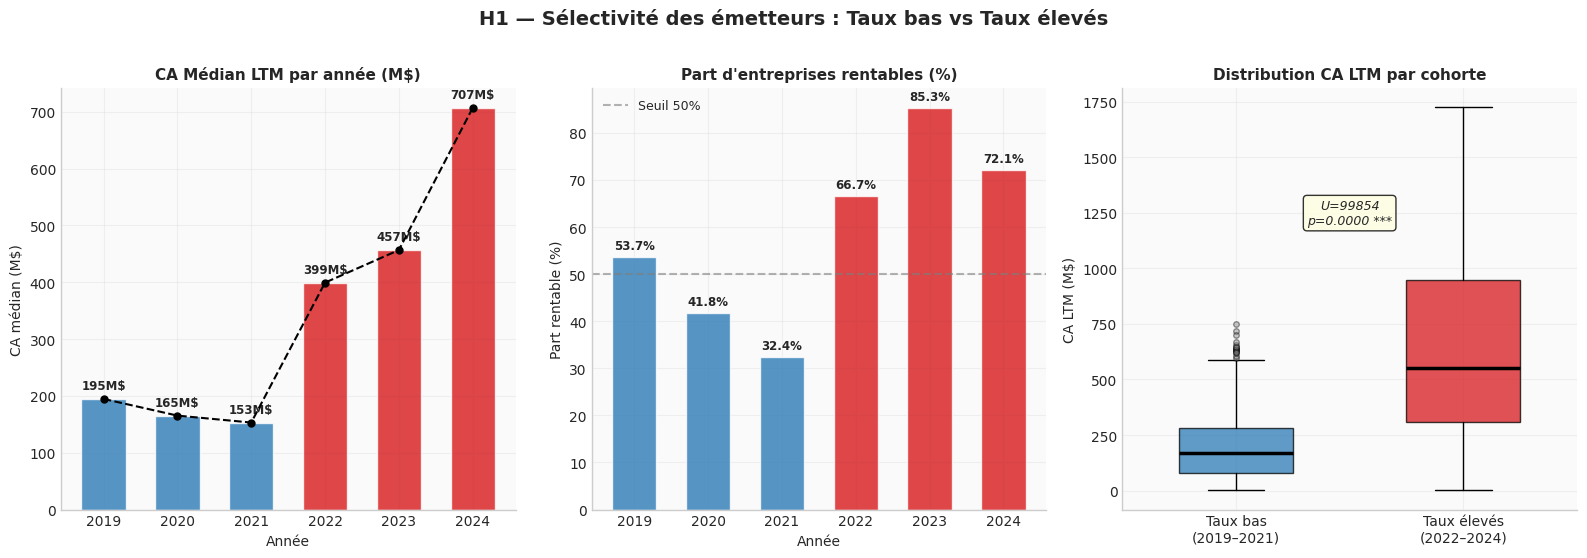

Fig 3 — OK


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 3 : Fondamentaux (H1 — Sélectivité)
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
fig.suptitle('H1 — Sélectivité des émetteurs : Taux bas vs Taux élevés', fontsize=14, fontweight='bold', y=1.01)

bar_c = [COLORS['low']] * 3 + [COLORS['high']] * 3

# ── 3a : CA Médian LTM par année
yearly_rev = all_ipo.groupby('year')['revenue_ltm'].median()
bars3a = axes[0].bar(yearly_rev.index, yearly_rev.values, color=bar_c, alpha=0.80, width=0.6, edgecolor='white')
axes[0].plot(yearly_rev.index, yearly_rev.values, 'k--o', linewidth=1.5, markersize=5, zorder=5)
axes[0].set_title('CA Médian LTM par année (M$)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('CA médian (M$)', fontsize=10)
axes[0].set_xlabel('Année', fontsize=10)
for x, y_val in zip(yearly_rev.index, yearly_rev.values):
    axes[0].text(x, y_val + 12, f'{y_val:.0f}M$', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

# ── 3b : Part d'entreprises rentables
yearly_prof = all_ipo.groupby('year')['profitable'].mean() * 100
bars3b = axes[1].bar(yearly_prof.index, yearly_prof.values, color=bar_c, alpha=0.80, width=0.6, edgecolor='white')
axes[1].axhline(y=50, color='gray', linestyle='--', alpha=0.6, linewidth=1.5, label='Seuil 50%')
axes[1].set_title('Part d\'entreprises rentables (%)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Part rentable (%)', fontsize=10)
axes[1].set_xlabel('Année', fontsize=10)
axes[1].legend(fontsize=9)
for x, y_val in zip(yearly_prof.index, yearly_prof.values):
    axes[1].text(x, y_val + 1, f'{y_val:.1f}%', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

# ── 3c : Boxplot CA LTM par cohorte (avec annotation MW)
rev_data = [low['revenue_ltm'], high['revenue_ltm']]
bp3 = axes[2].boxplot(rev_data,
                      labels=['Taux bas\n(2019–2021)', 'Taux élevés\n(2022–2024)'],
                      patch_artist=True, widths=0.5,
                      medianprops=dict(color='black', linewidth=2.5),
                      flierprops=dict(marker='o', markerfacecolor='gray', markersize=4, alpha=0.4))
bp3['boxes'][0].set_facecolor(COLORS['low']);  bp3['boxes'][0].set_alpha(0.75)
bp3['boxes'][1].set_facecolor(COLORS['high']); bp3['boxes'][1].set_alpha(0.75)
mw_h1 = mw_results['H1a — CA LTM']
axes[2].text(1.5, max(low['revenue_ltm'].quantile(0.90), high['revenue_ltm'].quantile(0.90)) * 0.95,
             f'U={mw_h1["stat"]:.0f}\np={mw_h1["p"]:.4f} ***',
             ha='center', fontsize=9, style='italic',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))
axes[2].set_title('Distribution CA LTM par cohorte', fontsize=11, fontweight='bold')
axes[2].set_ylabel('CA LTM (M$)', fontsize=10)

plt.tight_layout()
fig.savefig('fig3_fundamentals.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 3 — OK')

### Figure 4 — Matrice de corrélation

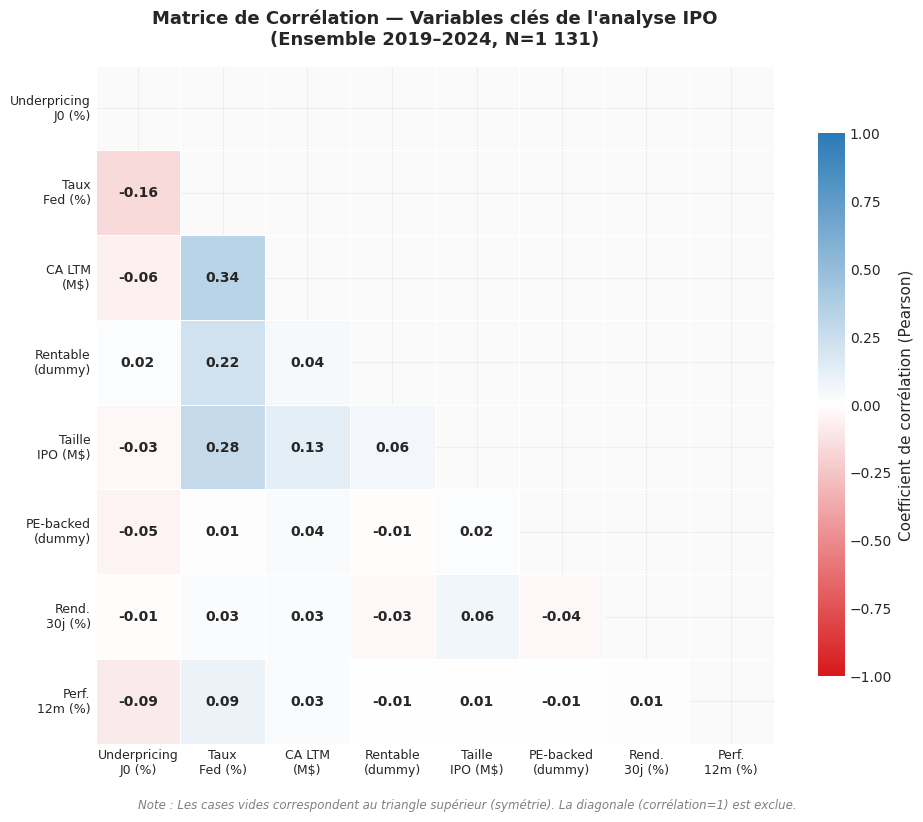

Fig 4 — Matrice de corrélation OK


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 4 : MATRICE DE CORRÉLATION
# ─────────────────────────────────────────────────────────────────────────────

corr_vars = {
    'underpricing': 'Underpricing\nJ0 (%)',
    'fed_rate':     'Taux\nFed (%)',
    'revenue_ltm':  'CA LTM\n(M$)',
    'profitable':   'Rentable\n(dummy)',
    'ipo_size_m':   'Taille\nIPO (M$)',
    'pe_backed':    'PE-backed\n(dummy)',
    'ret_30d':      'Rend.\n30j (%)',
    'ret_12m':      'Perf.\n12m (%)',
}

corr_data = all_ipo[list(corr_vars.keys())].dropna()
corr_matrix = corr_data.corr(method='pearson')

# Mask triangle supérieur
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))

# Colormap personnalisée
cmap = LinearSegmentedColormap.from_list(
    'ipo_corr', ['#D7191C', '#FFFFFF', '#2C7BB6'], N=256
)

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap=cmap,
    vmin=-1, vmax=1,
    annot=True, fmt='.2f',
    annot_kws={'size': 10, 'weight': 'bold'},
    square=True,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'shrink': 0.8, 'label': 'Coefficient de corrélation (Pearson)'},
    xticklabels=[corr_vars[v] for v in corr_vars.keys()],
    yticklabels=[corr_vars[v] for v in corr_vars.keys()],
    ax=ax
)

ax.set_title('Matrice de Corrélation — Variables clés de l\'analyse IPO\n(Ensemble 2019–2024, N=1 131)',
             fontsize=13, fontweight='bold', pad=15)
ax.tick_params(axis='x', rotation=0, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=9)

# Note de lecture
fig.text(0.5, -0.02,
         'Note : Les cases vides correspondent au triangle supérieur (symétrie). '
         'La diagonale (corrélation=1) est exclue.',
         ha='center', fontsize=8.5, color='gray', style='italic')

plt.tight_layout()
fig.savefig('fig4_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 4 — Matrice de corrélation OK')

### Figure 5 — Intervalles de confiance Bootstrap (95%)

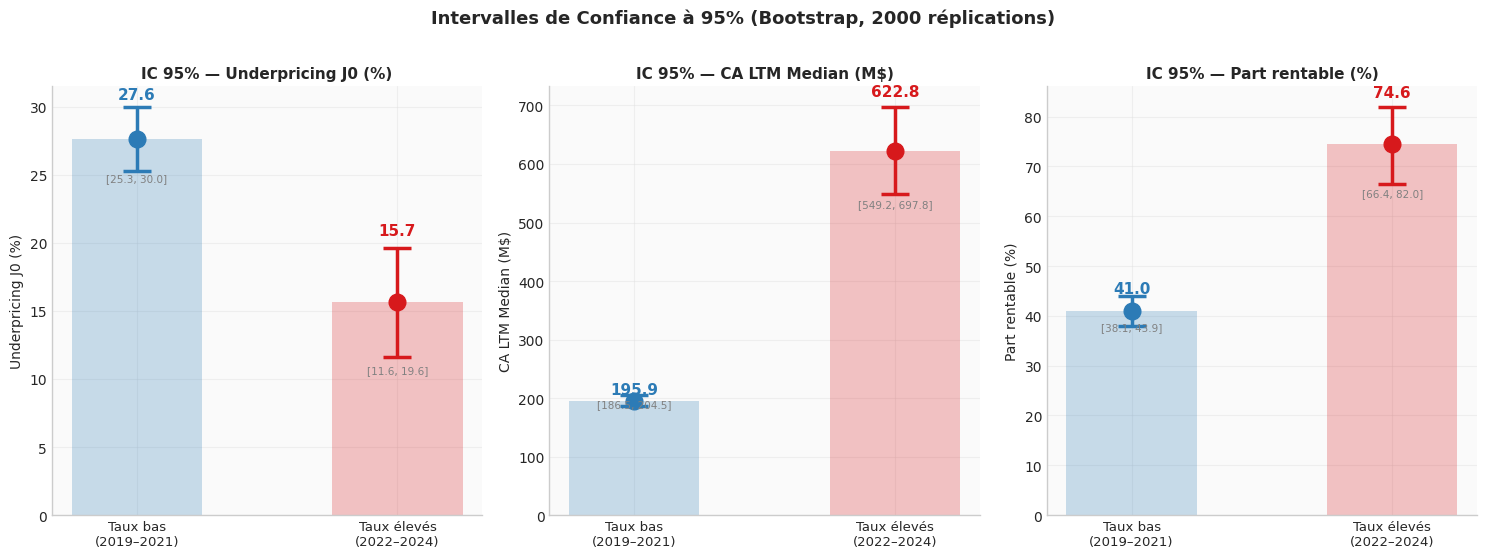

Fig 5 — Intervalles de confiance OK


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 5 : INTERVALLES DE CONFIANCE BOOTSTRAP
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))
fig.suptitle('Intervalles de Confiance à 95% (Bootstrap, 2000 réplications)', fontsize=13, fontweight='bold', y=1.01)

ic_plot_vars = [
    ('underpricing', 'Underpricing J0 (%)',  100),
    ('revenue_ltm',  'CA LTM Median (M$)',   1),
    ('profitable',   'Part rentable (%)',    100),
]

for ax, (var, title, scale) in zip(axes, ic_plot_vars):
    for i, (name, cohort, color, key) in enumerate([
        ('Taux bas\n(2019–2021)',    low,  COLORS['low'],  'low'),
        ('Taux élevés\n(2022–2024)', high, COLORS['high'], 'high'),
    ]):
        mean_val = cohort[var].mean() * scale
        ci       = ci_results[var][key] * scale
        ci_lo, ci_hi = ci[0], ci[1]

        # Barre de fond
        ax.bar(i, mean_val, color=color, alpha=0.25, width=0.5)
        # Point + IC
        ax.errorbar(i, mean_val, yerr=[[mean_val - ci_lo], [ci_hi - mean_val]],
                    fmt='o', color=color, markersize=12, capsize=10, capthick=2.5, elinewidth=2.5)
        # Valeur
        ax.text(i, ci_hi + abs(ci_hi - ci_lo) * 0.12,
                f'{mean_val:.1f}', ha='center', fontsize=11, fontweight='bold', color=color)
        # IC bornes
        ax.text(i, ci_lo - abs(ci_hi - ci_lo) * 0.15,
                f'[{ci_lo:.1f}, {ci_hi:.1f}]', ha='center', fontsize=7.5, color='gray')

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Taux bas\n(2019–2021)', 'Taux élevés\n(2022–2024)'], fontsize=9.5)
    ax.set_title(f'IC 95% — {title}', fontsize=11, fontweight='bold')
    ax.set_ylabel(title, fontsize=10)

plt.tight_layout()
fig.savefig('fig5_confidence_intervals.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 5 — Intervalles de confiance OK')

### Figure 6 — Régression OLS : Coefficients

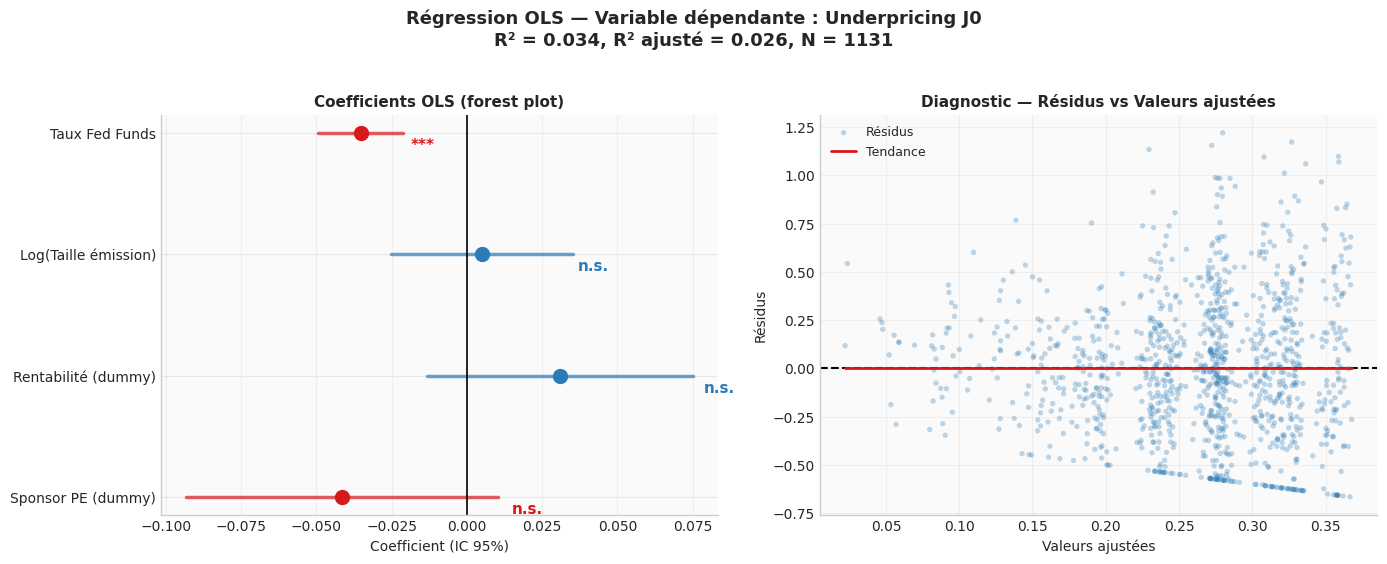

Fig 6 — OLS OK


In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 6 : OLS — Coefficients + Diagnostics
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle(f'Régression OLS — Variable dépendante : Underpricing J0\nR² = {model.rsquared:.3f}, R² ajusté = {model.rsquared_adj:.3f}, N = {len(y)}',
             fontsize=13, fontweight='bold', y=1.02)

# ── 6a : Coefficients OLS (forest plot)
coef_vars   = ['fed_rate', 'log_size', 'profitable', 'pe_backed']
coef_labels = ['Taux Fed Funds', 'Log(Taille émission)', 'Rentabilité (dummy)', 'Sponsor PE (dummy)']
coefs = [model.params[v]       for v in coef_vars]
pvals = [model.pvalues[v]      for v in coef_vars]
errs  = [model.bse[v] * 1.96   for v in coef_vars]
ci_lo = [c - e for c, e in zip(coefs, errs)]
ci_hi = [c + e for c, e in zip(coefs, errs)]

colors_c = [COLORS['high'] if c < 0 else COLORS['low'] for c in coefs]
y_pos    = range(len(coef_vars))

for i, (c, lo, hi, col, p) in enumerate(zip(coefs, ci_lo, ci_hi, colors_c, pvals)):
    axes[0].plot([lo, hi], [i, i], color=col, linewidth=2.5, alpha=0.7)
    axes[0].plot(c, i, 'o', color=col, markersize=10, zorder=5)
    axes[0].axhline(i, color='#EEE', linewidth=0.8, zorder=0)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'
    offset = max(abs(hi), abs(lo)) * 0.05
    axes[0].text(hi + offset, i + 0.1, sig, va='center', fontsize=11, fontweight='bold', color=col)

axes[0].axvline(x=0, color='black', linewidth=1.2, linestyle='-')
axes[0].set_yticks(list(y_pos))
axes[0].set_yticklabels(coef_labels, fontsize=10)
axes[0].set_xlabel('Coefficient (IC 95%)', fontsize=10)
axes[0].set_title('Coefficients OLS (forest plot)', fontsize=11, fontweight='bold')
axes[0].invert_yaxis()

# ── 6b : Résidus vs Valeurs ajustées (diagnostic)
fitted  = model.fittedvalues
resid   = model.resid
axes[1].scatter(fitted, resid, alpha=0.3, s=15, color=COLORS['low'],
                edgecolors='none', label='Résidus')
axes[1].axhline(0, color='black', linewidth=1.5, linestyle='--')
# Courbe tendance
z = np.polyfit(fitted, resid, 1)
p_fn = np.poly1d(z)
x_line = np.linspace(fitted.min(), fitted.max(), 100)
axes[1].plot(x_line, p_fn(x_line), color=COLORS['high'], linewidth=2, label='Tendance')
axes[1].set_xlabel('Valeurs ajustées', fontsize=10)
axes[1].set_ylabel('Résidus', fontsize=10)
axes[1].set_title('Diagnostic — Résidus vs Valeurs ajustées', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
fig.savefig('fig6_ols.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 6 — OLS OK')

### Figure 7 — Répartition sectorielle & Taille des émissions

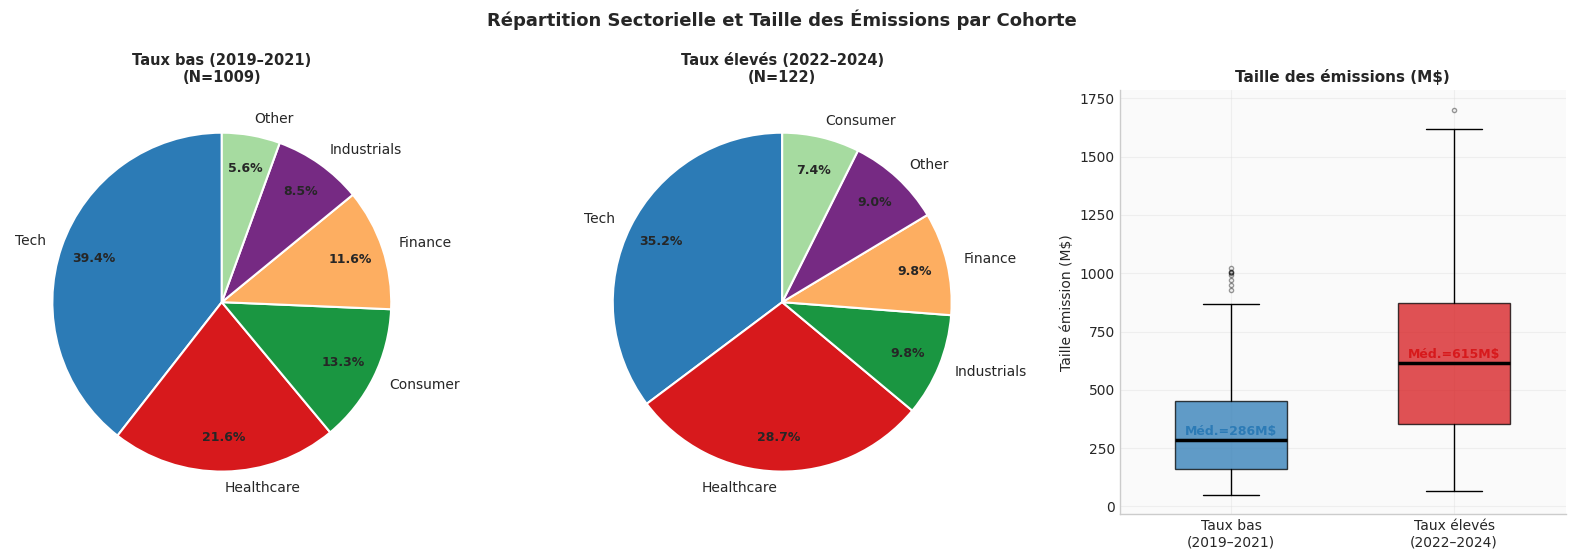

Fig 7 — Secteurs OK


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 7 : Répartition sectorielle + Taille des émissions
# ─────────────────────────────────────────────────────────────────────────────

sector_colors = ['#2C7BB6', '#D7191C', '#1A9641', '#FDAE61', '#762A83', '#A6DBA0']

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
fig.suptitle('Répartition Sectorielle et Taille des Émissions par Cohorte', fontsize=13, fontweight='bold', y=1.01)

# ── 7a & 7b : Pie charts sectoriels
for ax, (name, cohort) in zip(axes[:2], [('Taux bas (2019–2021)', low), ('Taux élevés (2022–2024)', high)]):
    sec_counts = cohort['sector'].value_counts()
    wedges, texts, autotexts = ax.pie(
        sec_counts.values, labels=sec_counts.index,
        autopct='%1.1f%%', colors=sector_colors[:len(sec_counts)],
        pctdistance=0.80, startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
    )
    for at in autotexts:
        at.set_fontsize(9)
        at.set_fontweight('bold')
    ax.set_title(f'{name}\n(N={len(cohort)})', fontsize=10.5, fontweight='bold')

# ── 7c : Boxplot taille d'émission par cohorte
bp7 = axes[2].boxplot([low['ipo_size_m'], high['ipo_size_m']],
                      labels=['Taux bas\n(2019–2021)', 'Taux élevés\n(2022–2024)'],
                      patch_artist=True, widths=0.5,
                      medianprops=dict(color='black', linewidth=2.5),
                      flierprops=dict(marker='o', markersize=3, alpha=0.4))
bp7['boxes'][0].set_facecolor(COLORS['low']);  bp7['boxes'][0].set_alpha(0.75)
bp7['boxes'][1].set_facecolor(COLORS['high']); bp7['boxes'][1].set_alpha(0.75)
axes[2].set_title('Taille des émissions (M$)', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Taille émission (M$)', fontsize=10)

# Moyennes annotées
for i, cohort in enumerate([low, high]):
    m = cohort['ipo_size_m'].median()
    axes[2].text(i+1, m + 20, f'Méd.={m:.0f}M$', ha='center', fontsize=9,
                 fontweight='bold', color=[COLORS['low'], COLORS['high']][i])

plt.tight_layout()
fig.savefig('fig7_sectors.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 7 — Secteurs OK')

### Figure 8 — Performance post-IPO (H3 & H4)

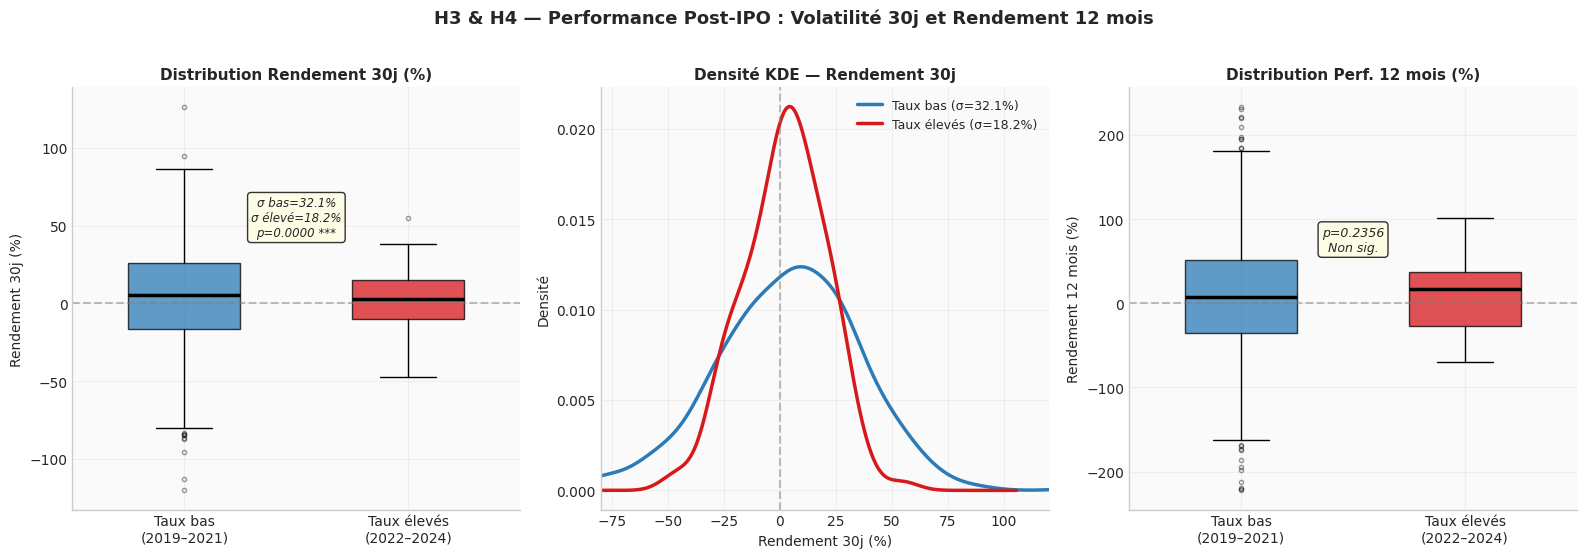

Fig 8 — Performance post-IPO OK


In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 8 : Performance post-IPO (H3 — 30j, H4 — 12m)
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
fig.suptitle('H3 & H4 — Performance Post-IPO : Volatilité 30j et Rendement 12 mois', fontsize=13, fontweight='bold', y=1.01)

# ── 8a : Boxplot rendement 30j
r30_low  = low['ret_30d']  * 100
r30_high = high['ret_30d'] * 100
bp8a = axes[0].boxplot([r30_low, r30_high],
                       labels=['Taux bas\n(2019–2021)', 'Taux élevés\n(2022–2024)'],
                       patch_artist=True, widths=0.5,
                       medianprops=dict(color='black', linewidth=2.5),
                       flierprops=dict(marker='o', markersize=3, alpha=0.4))
bp8a['boxes'][0].set_facecolor(COLORS['low']);  bp8a['boxes'][0].set_alpha(0.75)
bp8a['boxes'][1].set_facecolor(COLORS['high']); bp8a['boxes'][1].set_alpha(0.75)
axes[0].axhline(0, color='gray', linestyle='--', alpha=0.5)
mw_h3 = mw_results['H3 — Volatilité 30j']
axes[0].text(1.5, r30_low.quantile(0.90),
             f'σ bas={r30_low.std():.1f}%\nσ élevé={r30_high.std():.1f}%\np={mw_h3["p"]:.4f} ***',
             ha='center', fontsize=8.5, style='italic',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))
axes[0].set_title('Distribution Rendement 30j (%)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Rendement 30j (%)', fontsize=10)

# ── 8b : KDE rendement 30j
r30_low.plot.kde(ax=axes[1], color=COLORS['low'],  linewidth=2.5, label=f'Taux bas (σ={r30_low.std():.1f}%)')
r30_high.plot.kde(ax=axes[1], color=COLORS['high'], linewidth=2.5, label=f'Taux élevés (σ={r30_high.std():.1f}%)')
axes[1].axvline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_title('Densité KDE — Rendement 30j', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Rendement 30j (%)', fontsize=10)
axes[1].set_ylabel('Densité', fontsize=10)
axes[1].legend(fontsize=9)
axes[1].set_xlim(-80, 120)

# ── 8c : Rendement 12m (H4)
r12_low  = low_h4['ret_12m'].dropna()  * 100
r12_high = high_h4['ret_12m'].dropna() * 100
bp8c = axes[2].boxplot([r12_low, r12_high],
                       labels=['Taux bas\n(2019–2021)', 'Taux élevés\n(2022–2024)'],
                       patch_artist=True, widths=0.5,
                       medianprops=dict(color='black', linewidth=2.5),
                       flierprops=dict(marker='o', markersize=3, alpha=0.4))
bp8c['boxes'][0].set_facecolor(COLORS['low']);  bp8c['boxes'][0].set_alpha(0.75)
bp8c['boxes'][1].set_facecolor(COLORS['high']); bp8c['boxes'][1].set_alpha(0.75)
axes[2].axhline(0, color='gray', linestyle='--', alpha=0.5)
mw_h4 = mw_results['H4 — Perf. 12m']
axes[2].text(1.5, max(r12_low.quantile(0.80), r12_high.quantile(0.80)),
             f'p={mw_h4["p"]:.4f}\n{"Sig." if mw_h4["sig"] else "Non sig."}',
             ha='center', fontsize=9, style='italic',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))
axes[2].set_title('Distribution Perf. 12 mois (%)', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Rendement 12 mois (%)', fontsize=10)

plt.tight_layout()
fig.savefig('fig8_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 8 — Performance post-IPO OK')

### Figure 9 — Taux Fed vs Underpricing (scatter + régression)

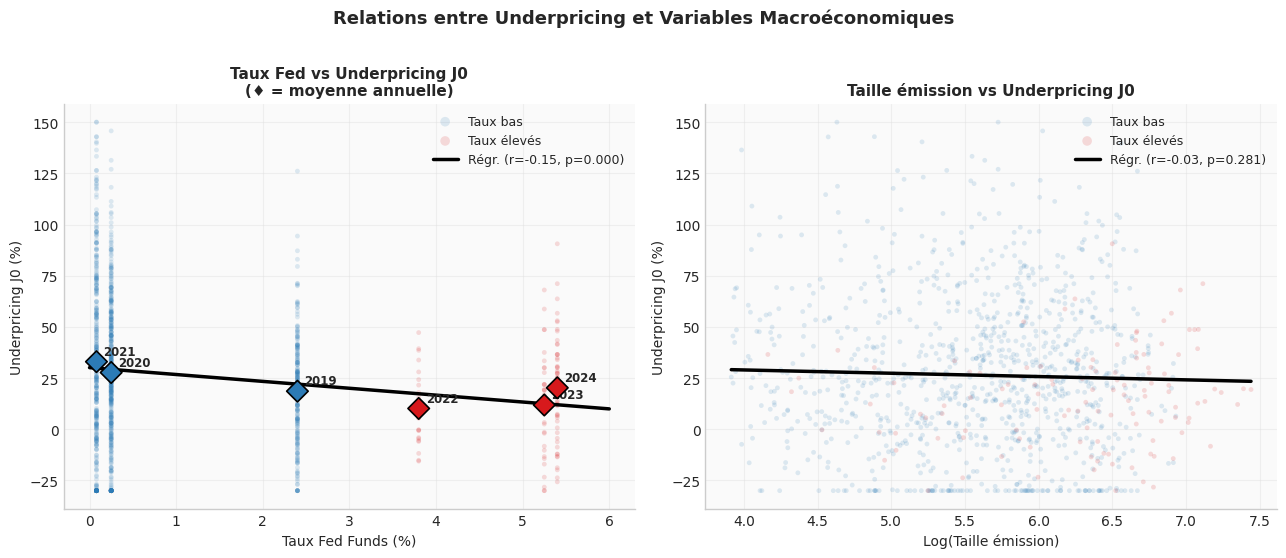

Fig 9 — Scatter OK


In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 9 : Scatter — Taux Fed vs Underpricing + Taille vs Underpricing
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
fig.suptitle('Relations entre Underpricing et Variables Macroéconomiques', fontsize=13, fontweight='bold', y=1.01)

# ── 9a : Taux Fed vs Underpricing
for name, cohort, color in [('Taux bas', low, COLORS['low']), ('Taux élevés', high, COLORS['high'])]:
    axes[0].scatter(cohort['fed_rate'], cohort['underpricing'] * 100,
                    color=color, alpha=0.15, s=12, edgecolors='none', label=name)

# Régression linéaire globale
x_fed = all_ipo['fed_rate'].values
y_up  = all_ipo['underpricing'].values * 100
slope, intercept, r_val, p_val, se = stats.linregress(x_fed, y_up)
x_line = np.linspace(0, 6, 100)
axes[0].plot(x_line, slope * x_line + intercept, 'k-', linewidth=2.5, label=f'Régr. (r={r_val:.2f}, p={p_val:.3f})')

# Moyennes annuelles
annual = all_ipo.groupby('year').agg({'fed_rate': 'first', 'underpricing': 'mean'}).reset_index()
axes[0].scatter(annual['fed_rate'], annual['underpricing'] * 100,
                c=[COLORS['low'] if y <= 2021 else COLORS['high'] for y in annual['year']],
                s=120, zorder=5, edgecolors='black', linewidth=1.2, marker='D')
for _, row in annual.iterrows():
    axes[0].annotate(str(int(row['year'])),
                     (row['fed_rate'], row['underpricing'] * 100),
                     textcoords='offset points', xytext=(5, 5), fontsize=8.5, fontweight='bold')

axes[0].set_xlabel('Taux Fed Funds (%)', fontsize=10)
axes[0].set_ylabel('Underpricing J0 (%)', fontsize=10)
axes[0].set_title('Taux Fed vs Underpricing J0\n(♦ = moyenne annuelle)', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9, markerscale=2)

# ── 9b : Log(Taille) vs Underpricing
for name, cohort, color in [('Taux bas', low, COLORS['low']), ('Taux élevés', high, COLORS['high'])]:
    axes[1].scatter(np.log(cohort['ipo_size_m']), cohort['underpricing'] * 100,
                    color=color, alpha=0.15, s=12, edgecolors='none', label=name)

# Régression
x_sz = np.log(all_ipo['ipo_size_m']).values
slope2, intercept2, r2, p2, _ = stats.linregress(x_sz, y_up)
x_line2 = np.linspace(x_sz.min(), x_sz.max(), 100)
axes[1].plot(x_line2, slope2 * x_line2 + intercept2, 'k-', linewidth=2.5, label=f'Régr. (r={r2:.2f}, p={p2:.3f})')
axes[1].set_xlabel('Log(Taille émission)', fontsize=10)
axes[1].set_ylabel('Underpricing J0 (%)', fontsize=10)
axes[1].set_title('Taille émission vs Underpricing J0', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9, markerscale=2)

plt.tight_layout()
fig.savefig('fig9_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 9 — Scatter OK')

### Figure 10 — Synthèse des résultats des hypothèses

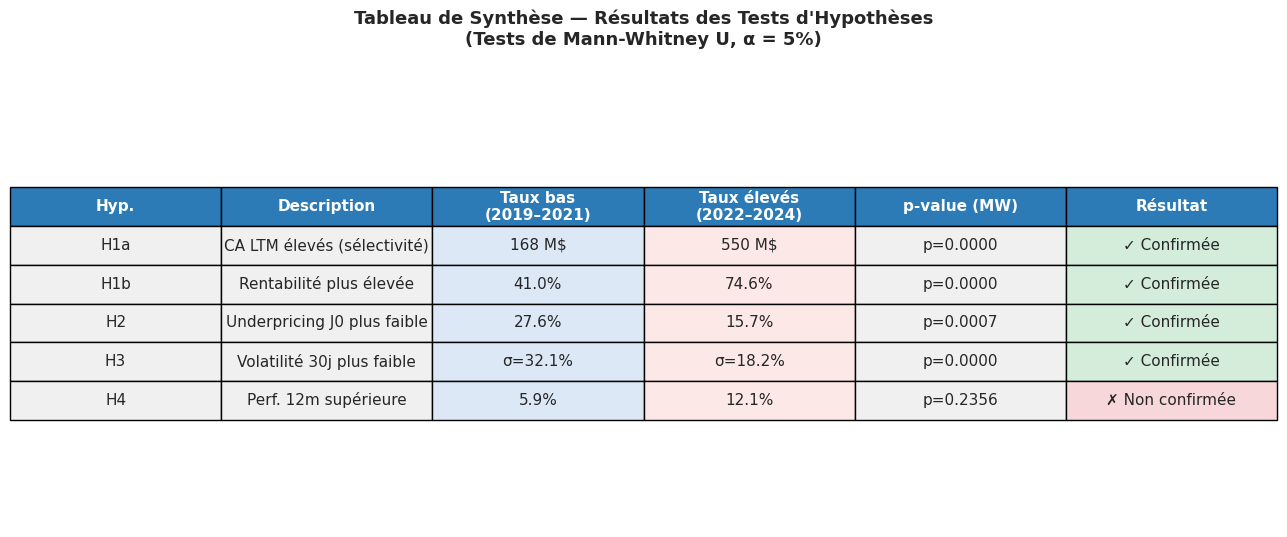

Fig 10 — Tableau de synthèse OK


In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 10 : Tableau de synthèse des hypothèses
# ─────────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.axis('off')

hypotheses = [
    ['H1a', 'CA LTM élevés (sélectivité)',
     f'{low["revenue_ltm"].median():.0f} M$', f'{high["revenue_ltm"].median():.0f} M$',
     f'p={mw_results["H1a — CA LTM"]["p"]:.4f}', '✓ Confirmée', '#d4edda'],
    ['H1b', 'Rentabilité plus élevée',
     f'{low["profitable"].mean()*100:.1f}%', f'{high["profitable"].mean()*100:.1f}%',
     f'p={mw_results["H1b — Rentabilité"]["p"]:.4f}', '✓ Confirmée', '#d4edda'],
    ['H2', 'Underpricing J0 plus faible',
     f'{low["underpricing"].mean()*100:.1f}%', f'{high["underpricing"].mean()*100:.1f}%',
     f'p={mw_results["H2 — Underpricing"]["p"]:.4f}', '✓ Confirmée', '#d4edda'],
    ['H3', 'Volatilité 30j plus faible',
     f'σ={low["ret_30d"].std()*100:.1f}%', f'σ={high["ret_30d"].std()*100:.1f}%',
     f'p={mw_results["H3 — Volatilité 30j"]["p"]:.4f}', '✓ Confirmée', '#d4edda'],
    ['H4', 'Perf. 12m supérieure',
     f'{h4_low.mean()*100:.1f}%', f'{h4_high.mean()*100:.1f}%',
     f'p={mw_results["H4 — Perf. 12m"]["p"]:.4f}',
     '✗ Non confirmée' if not mw_results['H4 — Perf. 12m']['sig'] else '✓ Confirmée',
     '#f8d7da' if not mw_results['H4 — Perf. 12m']['sig'] else '#d4edda'],
]

columns = ['Hyp.', 'Description', 'Taux bas\n(2019–2021)', 'Taux élevés\n(2022–2024)', 'p-value (MW)', 'Résultat']
cell_text = [[h[0], h[1], h[2], h[3], h[4], h[5]] for h in hypotheses]
cell_colors = [['#f0f0f0', '#f0f0f0', '#dce8f5', '#fde8e8', '#f0f0f0', h[6]] for h in hypotheses]

table = ax.table(
    cellText=cell_text,
    colLabels=columns,
    cellLoc='center',
    loc='center',
    cellColours=cell_colors,
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.2)

# Header
for j in range(len(columns)):
    table[0, j].set_facecolor('#2C7BB6')
    table[0, j].set_text_props(color='white', fontweight='bold')

ax.set_title('Tableau de Synthèse — Résultats des Tests d\'Hypothèses\n(Tests de Mann-Whitney U, α = 5%)',
             fontsize=13, fontweight='bold', pad=25)

plt.tight_layout()
fig.savefig('fig10_synthesis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 10 — Tableau de synthèse OK')

---
## 7. Synthèse finale et sauvegarde

In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# SAUVEGARDE RÉSULTATS
# ─────────────────────────────────────────────────────────────────────────────

import pickle

with open('results_complet.pkl', 'wb') as f:
    pickle.dump({
        'all_ipo':    all_ipo,
        'low':        low,
        'high':       high,
        'desc_df':    desc_df,
        'ci_results': ci_results,
        'mw_results': mw_results,
        'model':      model,
        'corr_matrix': corr_matrix,
    }, f)

print('══════════════════════════════════════════════')
print('  ✓ ANALYSE COMPLÈTE — RÉSULTATS')
print('══════════════════════════════════════════════')
print(f'  Total IPOs analysées      : {len(all_ipo)}')
print(f'  Cohorte Taux bas          : {len(low)} IPOs (2019–2021)')
print(f'  Cohorte Taux élevés       : {len(high)} IPOs (2022–2024)')
print()
print(f'  Underpricing moyen bas    : {low["underpricing"].mean()*100:.1f}%')
print(f'  Underpricing moyen élevé  : {high["underpricing"].mean()*100:.1f}%')
print(f'  CA médian bas             : {low["revenue_ltm"].median():.0f} M$')
print(f'  CA médian élevé           : {high["revenue_ltm"].median():.0f} M$')
print(f'  Part rentable bas         : {low["profitable"].mean()*100:.1f}%')
print(f'  Part rentable élevé       : {high["profitable"].mean()*100:.1f}%')
print()
print(f'  OLS R²                    : {model.rsquared:.4f}')
print(f'  Coeff. fed_rate           : {model.params["fed_rate"]:.4f} (p={model.pvalues["fed_rate"]:.4f} ***)')
print()
print('  Figures sauvegardées :')
figs = ['fig1_volume_rates', 'fig2_underpricing', 'fig3_fundamentals',
        'fig4_correlation_matrix', 'fig5_confidence_intervals', 'fig6_ols',
        'fig7_sectors', 'fig8_performance', 'fig9_scatter', 'fig10_synthesis']
for f in figs:
    print(f'    ✓ {f}.png')
print()
print('  ✓ results_complet.pkl sauvegardé')
print('══════════════════════════════════════════════')

══════════════════════════════════════════════
  ✓ ANALYSE COMPLÈTE — RÉSULTATS
══════════════════════════════════════════════
  Total IPOs analysées      : 1131
  Cohorte Taux bas          : 1009 IPOs (2019–2021)
  Cohorte Taux élevés       : 122 IPOs (2022–2024)

  Underpricing moyen bas    : 27.6%
  Underpricing moyen élevé  : 15.7%
  CA médian bas             : 168 M$
  CA médian élevé           : 550 M$
  Part rentable bas         : 41.0%
  Part rentable élevé       : 74.6%

  OLS R²                    : 0.0335
  Coeff. fed_rate           : -0.0354 (p=0.0000 ***)

  Figures sauvegardées :
    ✓ fig1_volume_rates.png
    ✓ fig2_underpricing.png
    ✓ fig3_fundamentals.png
    ✓ fig4_correlation_matrix.png
    ✓ fig5_confidence_intervals.png
    ✓ fig6_ols.png
    ✓ fig7_sectors.png
    ✓ fig8_performance.png
    ✓ fig9_scatter.png
    ✓ fig10_synthesis.png

  ✓ results_complet.pkl sauvegardé
══════════════════════════════════════════════
